# CGPA Prediction Model

Trained and evaluate a regression model using features.

--- TOP 10 POSITIVELY CORRELATED FEATURES ---
dstl_put_marks         0.351
maths4_put_marks       0.349
ds_put_marks           0.346
cyber_unit_5_marks     0.345
dstl_st1_marks         0.345
python_unit_2_marks    0.344
ds_st2_marks           0.343
cyber_st2_marks        0.342
cyber_put_marks        0.342
python_put_marks       0.342
Name: final_semester_grade, dtype: float64

--- TOP 5 NEGATIVELY CORRELATED FEATURES (Risk Indicators) ---
maths4_assignment_delay_hours   -0.260
cyber_assignment_delay_hours    -0.262
coa_assignment_delay_hours      -0.265
ds_assignment_delay_hours       -0.265
python_assignment_delay_hours   -0.274
Name: final_semester_grade, dtype: float64


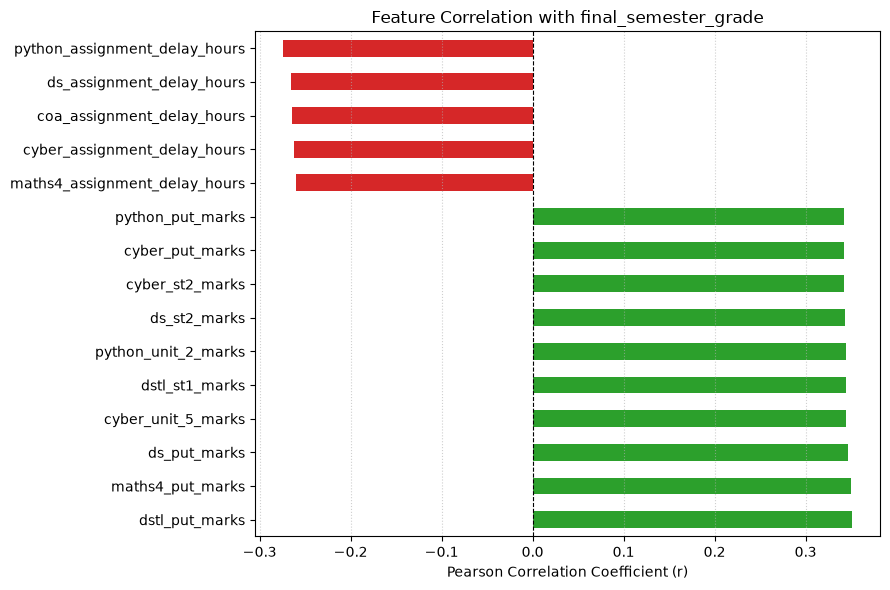

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df=pd.read_csv('../data/processed/edu_growth_cleaned.csv')

TARGET = 'final_semester_grade'

drop_cols = [
    'roll_no',
    'full_name',
    'grade_was_missing',
    'is_outlier_student',
    'outlier_count',
]

feature_df = df.drop(
    columns=[c for c in drop_cols if c in df.columns]
).dropna(subset=[TARGET])


numeric_df = feature_df.select_dtypes(include=[np.number])
correlations = (
    numeric_df.corr()[TARGET]
    .drop(index=[TARGET])
    .sort_values(ascending=False)
)

print('--- TOP 10 POSITIVELY CORRELATED FEATURES ---')
print(correlations.head(10).round(3))

print('\n--- TOP 5 NEGATIVELY CORRELATED FEATURES (Risk Indicators) ---')
print(correlations.tail(5).round(3))


plt.figure(figsize=(9, 6))
top_features = pd.concat([correlations.head(10), correlations.tail(5)])
top_features.plot(
    kind='barh',
    color=[
        '#2ca02c' if x >= 0 else '#d62728' for x in top_features.values
    ],
)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title(f'Feature Correlation with {TARGET}')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [95]:
import numpy as np
import pandas as pd


# One-Hot Encode sports_activity_level
sports_dummies = pd.get_dummies(
    df["sports_activity_level"], prefix="sports", dtype=int
)
df = pd.concat([df, sports_dummies], axis=1)

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

df.drop(index=df.query("is_outlier_student != 0 or grade_was_missing != 0 or outlier_count != 0").index, inplace=True)


X = df.drop(columns=[TARGET,'roll_no',
    'full_name','class_section','sports_activity_level','outlier_count',
 'is_outlier_student',
 'grade_was_missing',])
y = df[TARGET]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
print(f'R² Score: {r2_score(y_test, y_pred):.3f}')
print(f'MAE:      {mean_absolute_error(y_test, y_pred):.3f} CGPA points')
print(f'RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')

R² Score: 0.822
MAE:      0.347 CGPA points
RMSE:     0.434


In [74]:
X_train.shape

(24619, 99)

In [75]:
X_train.columns.to_list()

['overall_attendance_pct',
 'theory_attendance_pct',
 'practical_attendance_pct',
 'previous_cgpa',
 'medical_leave_days',
 'society_participation_pc',
 'coa_attendance_pct',
 'maths4_attendance_pct',
 'dstl_attendance_pct',
 'ds_attendance_pct',
 'python_attendance_pct',
 'cyber_attendance_pct',
 'lab_ds_attendance_pct',
 'lab_python_attendance_pct',
 'lab_coa_attendance_pct',
 'lab_cyber_attendance_pct',
 'coa_st1_marks',
 'coa_st2_marks',
 'coa_put_marks',
 'coa_unit_1_marks',
 'coa_unit_2_marks',
 'coa_unit_3_marks',
 'coa_unit_4_marks',
 'coa_unit_5_marks',
 'coa_assignment_score',
 'coa_assignment_delay_hours',
 'coa_quiz_score',
 'maths4_st1_marks',
 'maths4_st2_marks',
 'maths4_put_marks',
 'maths4_unit_1_marks',
 'maths4_unit_2_marks',
 'maths4_unit_3_marks',
 'maths4_unit_4_marks',
 'maths4_unit_5_marks',
 'maths4_assignment_score',
 'maths4_assignment_delay_hours',
 'maths4_quiz_score',
 'dstl_st1_marks',
 'dstl_st2_marks',
 'dstl_put_marks',
 'dstl_unit_1_marks',
 'dstl_uni

## RandomForest


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6, 
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("--- Random Forest Results ---")
print(f"R²:   {r2_score(y_test, rf_preds):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.3f}")

--- Random Forest Results ---
R²:   0.783
MAE:  0.383
RMSE: 0.479


In [ ]:
unit_test_cols = [col for col in df.columns if "_unit_" in col]

exclude_cols =unit_test_cols+[TARGET,'roll_no',
    'full_name','class_section','sports_activity_level','outlier_count',
 'is_outlier_student',
 'grade_was_missing',]
X = df.drop(columns=[col for col in exclude_cols if col in df.columns])
y = df[TARGET]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
print(f'R² Score: {r2_score(y_test, y_pred):.3f}')
print(f'MAE:      {mean_absolute_error(y_test, y_pred):.3f} CGPA points')
print(f'RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}')

R² Score: 0.821
MAE:      0.347 CGPA points
RMSE:     0.435


In [82]:
X_train.shape

(24619, 63)

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [100, 150, 250],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=reg,
    param_grid=param_grid,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

grid_search.fit(X_train, y_train)

print("=" * 45)
print("BEST HYPERPARAMETERS FOUND:")
print("=" * 45)
for param, val in grid_search.best_params_.items():
    print(f"  {param:<18}: {val}")

# Best estimator
best_model = grid_search.best_estimator_

test_preds = best_model.predict(X_test)
print("\n" + "=" * 45)
print("TEST SET METRICS (BEST MODEL):")
print("=" * 45)
print(f"  R² Score:  {r2_score(y_test, test_preds):.3f}")
print(f"  MAE:       {mean_absolute_error(y_test, test_preds):.3f}")
print(f"  RMSE:      {np.sqrt(mean_squared_error(y_test, test_preds)):.3f}")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
BEST HYPERPARAMETERS FOUND:
  colsample_bytree  : 0.7
  learning_rate     : 0.03
  max_depth         : 6
  min_child_weight  : 3
  n_estimators      : 250
  subsample         : 1.0

TEST SET METRICS (BEST MODEL):
  R² Score:  0.826
  MAE:       0.342
  RMSE:      0.428


In [85]:
test_errors = np.abs(y_test - best_model.predict(X_test))
benchmark_mae = float(np.mean(test_errors))  # ~0.342


#  Prediction function returning  grade and confidence
def get_prediction_confidence(model, student_data, benchmark_err=benchmark_mae):

    preds = model.predict(student_data)

    results = []
    for pred in preds:
        grade_clipped = float(np.clip(pred, 0.0, 10.0))
        dist_from_median = abs(grade_clipped - 7.5) / 5.0
        confidence = 100.0 * (1.0 - (benchmark_err / 2.0) - (0.05 * dist_from_median))
        confidence = float(np.clip(confidence, 65.0, 98.0))

        results.append(
            {
                "Predicted_Grade": round(grade_clipped, 2),
                "Confidence_Score": f"{round(confidence, 1)}%",
            }
        )

    return pd.DataFrame(results)

In [92]:
# example
single_student = X_test.iloc[[0]]
output = get_prediction_confidence(best_model, single_student)

print(f"Predicted Grade:  {output.loc[0, 'Predicted_Grade']}")
print(f"Confidence Score: {output.loc[0, 'Confidence_Score']}")

Predicted Grade:  6.79
Confidence Score: 82.2%


In [94]:
import joblib
import numpy as np
import pandas as pd

benchmark_mae = float(np.mean(np.abs(y_test - best_model.predict(X_test))))


class StudentGradePredictor:

    def __init__(self, model, feature_columns, benchmark_err=benchmark_mae):
        self.model = model
        self.feature_columns = feature_columns
        self.benchmark_err = benchmark_err

    def get_prediction_confidence(self, student_data):
        # Enforce column order and selection
        data_aligned = student_data[self.feature_columns]
        preds = self.model.predict(data_aligned)

        results = []
        for pred in preds:
            grade_clipped = float(np.clip(pred, 0.0, 10.0))
            dist_from_median = abs(grade_clipped - 7.5) / 5.0
            confidence = 100.0 * (
                1.0 - (self.benchmark_err / 2.0) - (0.05 * dist_from_median)
            )
            confidence = float(np.clip(confidence, 65.0, 98.0))

            results.append(
                {
                    "Predicted_Grade": round(grade_clipped, 2),
                    "Confidence_Score": f"{round(confidence, 1)}%",
                }
            )

        return pd.DataFrame(results)



predictor_bundle = StudentGradePredictor(
    model=best_model,
    feature_columns=list(X_train.columns),
    benchmark_err=benchmark_mae,
)

joblib.dump(predictor_bundle, "..\\artifacts\\student_grade_predictor.pkl")
print("Saved model and confidence scoring function to student_grade_predictor.pkl")

Saved model and confidence scoring function to student_grade_predictor.pkl
